In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')

# 1. Učitavanje podataka
member_df = pd.read_csv('member_stats_training.csv')
train_matches = pd.read_csv('clan_matches_training.csv')

Osnovni Feature Engineering

In [2]:
# 2. Ciljani Feature Engineering (Samo za feature koji su se pokazali korisnim)
def prepare_essential_features(member_df, matches_df):
    df = member_df.copy()
    
    # Agregacija SAMO onoga što nam treba za finalni model
    agg_logic = {
        'avg_training_bonus': ['min', 'mean'],
    }
    
    clan_feats = df.groupby('clan_id').agg(agg_logic)
    clan_feats.columns = ['bonus_min', 'bonus_mean']
    clan_feats = clan_feats.reset_index()
    
    # Spajanje sa mečevima
    df_final = matches_df.merge(clan_feats, left_on='clan_1_id', right_on='clan_id')
    df_final = df_final.merge(clan_feats, left_on='clan_2_id', right_on='clan_id', suffixes=('_c1', '_c2'))
    
    # Kreiranje finalnih razlika i količnika
    df_final['bonus_min_diff'] = df_final['bonus_min_c1'] - df_final['bonus_min_c2']
    df_final['bonus_min_ratio'] = (df_final['bonus_min_c1'] + 0.01) / (df_final['bonus_min_c2'] + 0.01)
    df_final['bonus_mean_ratio'] = (df_final['bonus_mean_c1'] + 0.01) / (df_final['bonus_mean_c2'] + 0.01)
    
    return df_final

df_final = prepare_essential_features(member_df, train_matches)

Optuna Hyperparameter Tuning za XGBoost

In [10]:
# Definisanje X, y i težina za finalno modelovanje
feature_short = ['bonus_min_ratio', 'bonus_min_diff', 'bonus_mean_ratio']

# power = ['power_index_mean_diff', 'power_index_mean_ratio']
# X = df_final[feature_short + power]

X = df_final[feature_short]
y = df_final['clan_winner'] - 1 
W = (df_final['clan_1_points'] - df_final['clan_2_points']).abs() + 1 

# Split za Optunu
X_train_opt, X_val_opt, y_train_opt, y_val_opt, w_train_opt, w_val_opt = train_test_split(
    X, y, W, test_size=0.25, random_state=0
)

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.1, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 50.0, log=True),
        'random_state': 47,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**param)
    model.fit(X_train_opt, y_train_opt, sample_weight=w_train_opt)
    preds = model.predict(X_val_opt)
    return accuracy_score(y_val_opt, preds)

study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50) # Otkomentarisati za pokretanje pretrage

# Ugrađujemo već pronađene najbolje parametre u finalni model
best_optuna_params = {
    'n_estimators': 138, 
    'learning_rate': 0.022, 
    'max_depth': 4,    
    'subsample': 0.68,
    'reg_alpha': 0.0172,   
    'reg_lambda': 0.161,
    'gamma': 2.182,
    'min_child_weight': 12,
    'colsample_bytree': 1,
    'random_state': 47,
    'eval_metric': 'logloss'
}

[I 2026-04-30 23:04:51,934] A new study created in memory with name: no-name-266361a7-6447-479b-ba13-4e1f8afaf901


Finalni Trening i Validacija: evaluacija preko 5 K-fold

In [11]:
# Inicijalizacija finalnog modela
cv_model = XGBClassifier(**best_optuna_params)

# K-Fold Unakrsna Validacija
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=47)
acc_scores = []

print(f"{'Fold':<5} | {'Val Acc':<10}")
print("-" * 25)

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_tr_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    w_tr_cv = W.iloc[train_idx]

    cv_model.fit(X_tr_cv, y_tr_cv, sample_weight=w_tr_cv)
    preds_val = cv_model.predict(X_val_cv)
    
    acc_val = accuracy_score(y_val_cv, preds_val)
    acc_scores.append(acc_val)
    print(f"{i+1:<5} | {acc_val:<10.4f}")

print("-" * 25)
print(f"Srednji Accuracy: {np.mean(acc_scores):.4f} (+/- {np.std(acc_scores):.4f})")

# Finalni trening na celom setu
final_model = XGBClassifier(**cv_model.get_params())
final_model.fit(X, y, sample_weight=W)

Fold  | Val Acc   
-------------------------
1     | 0.5955    
2     | 0.5926    
3     | 0.5889    
4     | 0.5876    
5     | 0.5763    
-------------------------
Srednji Accuracy: 0.5882 (+/- 0.0066)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

Vizualizacija i metrike

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.60      0.59     12126
           1       0.59      0.58      0.59     12162

    accuracy                           0.59     24288
   macro avg       0.59      0.59      0.59     24288
weighted avg       0.59      0.59      0.59     24288



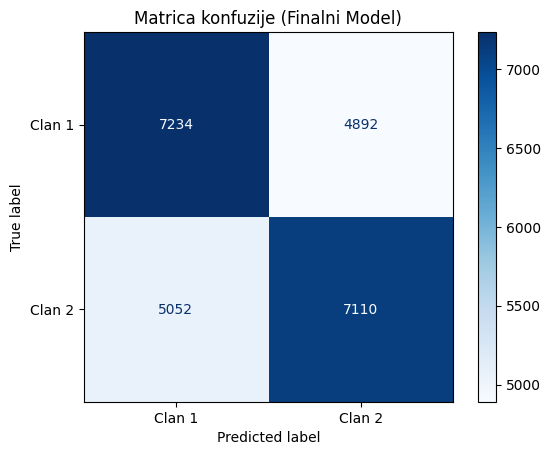

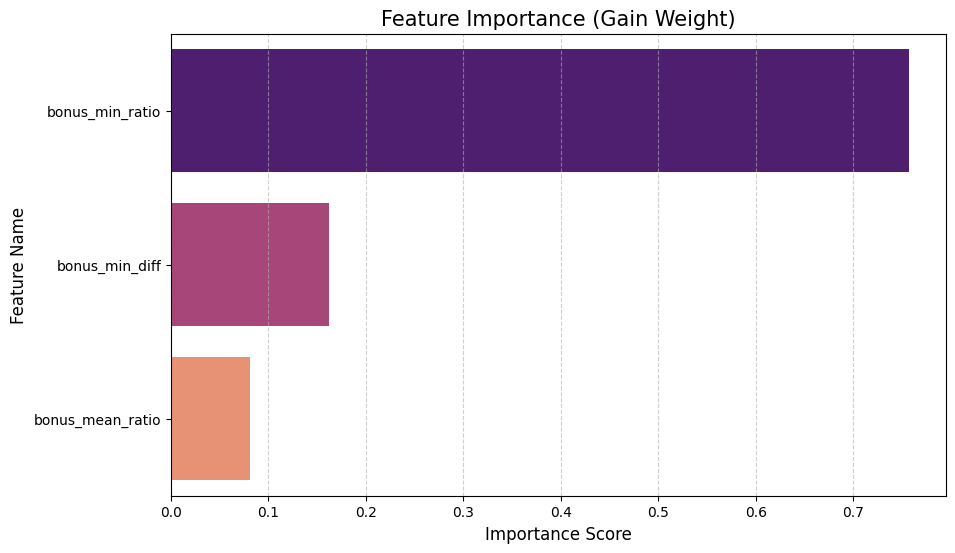

In [12]:
# Prikaz na celom setu čisto da vidimo distribuciju
train_preds = final_model.predict(X)
print("Classification Report:\n", classification_report(y, train_preds))

# Matrica konfuzije
cm = confusion_matrix(y, train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clan 1", "Clan 2"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matrica konfuzije (Finalni Model)')
plt.show()

# Prikaz Feature Importance
importances = final_model.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='magma')
plt.title('Feature Importance (Gain Weight)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Submitovanje resenja

In [ ]:

print("Započinjem generisanje submission fajla...")

# 1. Učitavanje test podataka
try:
    member_test_df = pd.read_csv('member_stats_test.csv')
    test_matches = pd.read_csv('clan_matches_test.csv')
    print("Test podaci uspešno učitani.")
except FileNotFoundError:
    print("Greška: Test fajlovi nisu pronađeni. Proverite putanje do fajlova.")
    # Prekidamo dalje izvršavanje ove ćelije ako nema fajlova
    raise 

# 2. Primena istog Feature Engineering-a na test set
# Koristimo funkciju koju smo ranije definisali
df_test_final = prepare_essential_features(member_test_df, test_matches)

# Izdvajanje X za predikciju (mora biti isti skup i redosled kolona kao u treningu)
X_test = df_test_final[feature_short]

# 3. Generisanje predikcija pomoću finalnog modela
print("Generišem predikcije...")
# Model vraća 0 i 1, moramo vratiti u originalne klase (1 i 2)
test_preds_01 = final_model.predict(X_test)
test_preds_original = test_preds_01 + 1 

# 4. Kreiranje finalnog DataFrame-a u traženom formatu
submission_df = pd.DataFrame({
    'clan_1_id': df_test_final['clan_1_id'],
    'clan_2_id': df_test_final['clan_2_id'],
    'predicted_clan_winner': test_preds_original
})

# 5. Čuvanje u CSV
csv_filename = "clan_winner_predictions.csv"
submission_df.to_csv(csv_filename, index=False)
print(f"Uspesno! Predikcije su sačuvane u fajl: {csv_filename}")

# Prikaz prvih par redova da potvrdimo format
print("\nIzgled submission fajla (prvih 5 redova):")
display(submission_df.head())

Smart assistant

In [ ]:

import pandas as pd

def smart_assistant_ultimate(clan_1_id, clan_2_id, current_df, model):
    """
    Ultimate Bot koji rešava problem 'Pomerajućeg minimuma' (Shifting Minimum).
    Koristi Greedy algoritam da ravnomerno rasporedi treninge na najslabije igrače 
    dok šanse ne prebace 50%.
    """
    print(f"\n🤖 SMART ASSISTANT: Ultimate Algoritam | {clan_1_id} vs {clan_2_id}")
    print("-" * 75)
    
    clan1_members = current_df[current_df['clan_id'] == clan_1_id].copy()
    clan2_members = current_df[current_df['clan_id'] == clan_2_id].copy()
    
    if clan1_members.empty or clan2_members.empty:
        print("Greška: Jedan od klanova nije pronađen u podacima.")
        return
        
    # Protivnički podaci ostaju fiksni
    c2_bonus_min = clan2_members['avg_training_bonus'].min()
    c2_bonus_mean = clan2_members['avg_training_bonus'].mean()
    
    # Rečnik za NAŠ klan: user_id -> trenutni trening bonus
    current_bonuses = clan1_members.set_index('user_id')['avg_training_bonus'].to_dict()
    
    # Maksimalni mogući bonus u igri iščitavamo iz podataka (da ne preteramo)
    MAX_BONUS = current_df['avg_training_bonus'].max()
    
    # Helper funkcija za komunikaciju sa XGBoost modelom
    def calculate_win_prob(b_min_1, b_mean_1):
        sim_data = pd.DataFrame({
            'bonus_min_ratio': [(b_min_1 + 0.01) / (c2_bonus_min + 0.01)],
            'bonus_min_diff': [b_min_1 - c2_bonus_min],
            'bonus_mean_ratio': [(b_mean_1 + 0.01) / (c2_bonus_mean + 0.01)]
        })
        return model.predict_proba(sim_data)[0][0] 
    
    # 1. Početno stanje
    initial_min = min(current_bonuses.values())
    initial_mean = sum(current_bonuses.values()) / len(current_bonuses)
    current_prob = calculate_win_prob(initial_min, initial_mean)
    
    print(f"📊 Trenutne šanse za pobedu klana {clan_1_id}: {current_prob*100:.1f}%\n")
    
    if current_prob >= 0.50:
        print("✅ Već ste favoriti! Preporučujemo održavanje trenutne forme.")
        return

    print("🚨 ŠANSE SU ISPOD 50%. POKREĆEM GREEDY ALGORITAM ZA OPTIMALNU RASPODELU TRENINGA...")
    
    # Rečnik koji pamti koliko je kojem igraču bot "dodao" treninga
    added_bonuses = {user: 0.0 for user in current_bonuses.keys()}
    target_reached = False
    
    # 2. Greedy petlja (korak po korak)
    while True:
        # A. Tražimo ko TRENUTNO ima najmanji bonus u rečniku
        current_min = min(current_bonuses.values())
        
        # Ako smo sve igrače nabili do maksimalnog bonusa u igri, izlazimo
        if current_min >= MAX_BONUS:
            break
            
        # Izdvajamo sve igrače koji trenutno dele taj minimum
        worst_users = [u for u, b in current_bonuses.items() if b == current_min]
        
        # B. Uzimamo samo PRVOG igrača iz te grupe i dajemo mu samo +1% (ili do maksimuma)
        target_user = worst_users[0]
        increment = min(1.0, MAX_BONUS - current_bonuses[target_user])
        
        current_bonuses[target_user] += increment
        added_bonuses[target_user] += increment
        
        # C. Računamo novi minimum i prosek za ceo klan
        new_min = min(current_bonuses.values())
        new_mean = sum(current_bonuses.values()) / len(current_bonuses)
        
        # D. Pitamo model kolike su nam sada šanse
        new_prob = calculate_win_prob(new_min, new_mean)
        
        # Ako smo napokon preskočili 50% šansi, zaustavljamo simulaciju!
        if new_prob > 0.50:
            target_reached = True
            break

    # 3. Ispis konačnog izveštaja klana
    if target_reached:
        print(f"\n🎯 PRONAĐENA OPTIMALNA RASPODELA! Šanse skaču na {new_prob*100:.1f}%.")
        print("Najefikasniji plan treninga koji ravnomerno raspoređuje teret:")
        for user, added in added_bonuses.items():
            if added > 0:
                original = current_bonuses[user] - added
                print(f"  -> Igrač {user}: mora da podigne bonus za +{added:.1f}% (sa {original:.1f}% na {current_bonuses[user]:.1f}%)")
    else:
        print(f"\n❌ NEMOGUĆA MISIJA:")
        print("Čak i da svi igrači sa slabijim bonusima treniraju do apsolutnog maksimuma, šanse ostaju ispod 50%.")
        print("Protivnik ima preveliku prednost u osnovnim atributima (zvezdicama). Čuvajte koferčiće za sledeći turnir!")

In [36]:
for i in range(1,10):
    sample_match = train_matches.iloc[i]
    c1 = sample_match['clan_1_id']
    c2 = sample_match['clan_2_id']

    smart_assistant_ultimate(clan_1_id=c1, clan_2_id=c2, current_df=member_df, model=final_model)


🤖 SMART ASSISTANT: Ultimate Algoritam | clan_5202 vs clan_16269
---------------------------------------------------------------------------
📊 Trenutne šanse za pobedu klana clan_5202: 47.3%

🚨 ŠANSE SU ISPOD 50%. POKREĆEM GREEDY ALGORITAM ZA OPTIMALNU RASPODELU TRENINGA...

🎯 PRONAĐENA OPTIMALNA RASPODELA! Šanse skaču na 61.3%.
Najefikasniji plan treninga koji ravnomerno raspoređuje teret:
  -> Igrač user_6208: mora da podigne bonus za +1.0% (sa 0.0% na 1.0%)
  -> Igrač user_9147: mora da podigne bonus za +1.0% (sa 0.0% na 1.0%)
  -> Igrač user_11543: mora da podigne bonus za +1.0% (sa 0.0% na 1.0%)
  -> Igrač user_26086: mora da podigne bonus za +1.0% (sa 0.0% na 1.0%)

🤖 SMART ASSISTANT: Ultimate Algoritam | clan_26609 vs clan_2868
---------------------------------------------------------------------------
📊 Trenutne šanse za pobedu klana clan_26609: 51.9%

✅ Već ste favoriti! Preporučujemo održavanje trenutne forme.

🤖 SMART ASSISTANT: Ultimate Algoritam | clan_5093 vs clan_37398
-